# Motor vs potmon — hysteresis / backlash loop

File: `metadata_20260627_173152.h5`. Azimuth only.

Step 4: characterise the motor step-count error. potmon (≈ IMU, the trusted
truth) on the x-axis, motor `az_pos` on the y-axis, **colored by sweep
direction**. Pot is shifted by its measured +0.71 s lag (notebook 03) so the
loop reflects mechanics, not timing.

- **Backlash** → up-sweep and down-sweep branches separated by a constant
  vertical gap (dead-band on reversal).
- **Cumulative step loss** → the branches drift apart / the loop fails to
  close back on itself.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_metadata_hdf5

FNAME = "metadata_20260627_173152.h5"
here = Path.cwd()
data_path = next(
    (p / FNAME for p in [here, *here.parents] if (p / FNAME).exists()), None
)
assert data_path is not None, f"could not find {FNAME} above {here}"
meta = read_metadata_hdf5(data_path)

STREAMS = ["motor", "potmon", "imu_az"]
T0 = min(s["_ts_unix"] for k in STREAMS for s in meta[k] if s is not None)


def series(stream, field, drop_error=True):
    rows = []
    for s in meta[stream]:
        if s is None or (drop_error and s.get("status") == "error"):
            continue
        val = s.get(field)
        if val is None:
            continue
        rows.append((s["_ts_unix"] - T0, val))
    rows.sort(key=lambda r: r[0])
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])


t_i, yaw = series("imu_az", "yaw")
imu_deg = np.unwrap(yaw, period=360.0)
t_m, steps = series("motor", "az_pos")
t_p, volts = series("potmon", "pot_az_voltage")
a, b = np.polyfit(np.interp(t_i, t_m, steps), imu_deg, 1)
c, d = np.polyfit(np.interp(t_i, t_p, volts), imu_deg, 1)
motor_deg = a * steps + b
pot_deg = c * volts + d

In [2]:
# Common 20 Hz grid; pot lag-corrected into the motor time frame.
TAU_PM = 0.71  # pot lags motor (notebook 03)
DT = 0.05
lo = max(t_i.min(), t_m.min(), t_p.min()) + TAU_PM + DT
hi = min(t_i.max(), t_m.max(), t_p.max()) - DT
grid = np.arange(lo, hi, DT)

m = np.interp(grid, t_m, motor_deg)
true = np.interp(grid + TAU_PM, t_p, pot_deg)  # pot, lag-aligned to motor

# Sweep direction from smoothed d(true)/dt.
win = int(round(1.0 / DT))  # 1 s moving average
kern = np.ones(win) / win
true_s = np.convolve(true, kern, mode="same")
vel = np.gradient(true_s, grid)
THRESH = 0.3  # deg/s; below this = dwell
up = vel > THRESH
down = vel < -THRESH
dwell = ~(up | down)
print(f"up={up.sum()}  down={down.sum()}  dwell={dwell.sum()} samples")

up=3566  down=3631  dwell=511 samples


In [3]:
# Quantify branch separation vs azimuth: bin the residual (motor-true) by
# true azimuth for up and down sweeps. Constant gap = backlash; gap that
# trends with azimuth = step loss / nonlinearity.
resid = m - true
edges = np.linspace(true.min(), true.max(), 16)
ctr = 0.5 * (edges[:-1] + edges[1:])


def binned(mask):
    idx = np.digitize(true[mask], edges) - 1
    out = np.full(len(ctr), np.nan)
    for k in range(len(ctr)):
        sel = idx == k
        if sel.sum() > 3:
            out[k] = np.median(resid[mask][sel])
    return out


up_b, down_b = binned(up), binned(down)
gap = up_b - down_b
both = ~np.isnan(gap)
print(f"up-sweep   median residual: {np.nanmedian(up_b):+6.2f} deg")
print(f"down-sweep median residual: {np.nanmedian(down_b):+6.2f} deg")
print(
    f"up-down branch gap: median {np.nanmedian(gap[both]):+5.2f} deg, "
    f"range {np.nanmin(gap[both]):+.1f}..{np.nanmax(gap[both]):+.1f} deg"
)

up-sweep   median residual:  +2.41 deg
down-sweep median residual:  +3.55 deg
up-down branch gap: median -0.39 deg, range -3.0..+4.1 deg


saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/motor_pot_imu/04_hysteresis.png


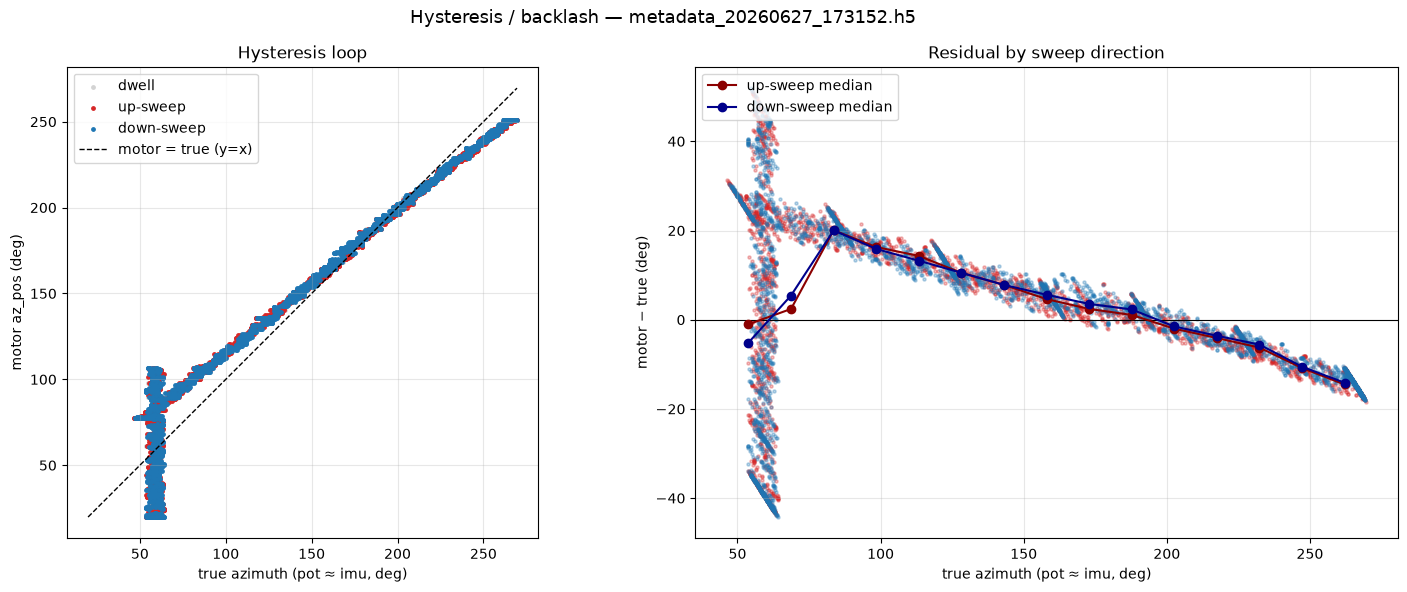

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel A: motor vs true (hysteresis loop) ---
ax0.scatter(true[dwell], m[dwell], s=6, c="lightgray", label="dwell")
ax0.scatter(true[up], m[up], s=6, c="tab:red", label="up-sweep")
ax0.scatter(true[down], m[down], s=6, c="tab:blue", label="down-sweep")
lim = [min(true.min(), m.min()), max(true.max(), m.max())]
ax0.plot(lim, lim, "k--", lw=1, label="motor = true (y=x)")
ax0.set_xlabel("true azimuth (pot \u2248 imu, deg)")
ax0.set_ylabel("motor az_pos (deg)")
ax0.set_title("Hysteresis loop")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
ax0.set_aspect("equal", adjustable="box")

# --- Panel B: residual vs azimuth, with binned branch medians ---
ax1.axhline(0, color="k", lw=0.8)
ax1.scatter(true[up], resid[up], s=5, c="tab:red", alpha=0.3)
ax1.scatter(true[down], resid[down], s=5, c="tab:blue", alpha=0.3)
ax1.plot(ctr, up_b, "o-", c="darkred", label="up-sweep median")
ax1.plot(ctr, down_b, "o-", c="darkblue", label="down-sweep median")
ax1.set_xlabel("true azimuth (pot \u2248 imu, deg)")
ax1.set_ylabel("motor \u2212 true (deg)")
ax1.set_title("Residual by sweep direction")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

fig.suptitle(
    "Hysteresis / backlash \u2014 metadata_20260627_173152.h5", fontsize=13
)
fig.tight_layout()
out = Path.cwd() / "04_hysteresis.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)